# Classification by Chord Changes
Loads a `.wav` file, splits it into 5 consecutive 2-second chunks, and plots a Constant Q-Transform (CQT) spectrogram for each chunk.

In [1]:
import librosa
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scienceplots
import song_analysis_utils

%matplotlib inline

/Users/xbaca/Desktop/UC3M/Thesis/chordcluster/.venv/lib/python3.13/site-packages/chord_extractor/extractors/chordino.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
Please make sure VAMP_PATH is specified pointing to the directory containing the appropriate compiled library for Chordino. This can be sourced by using the Vamp Plugin Pack installer at https://code.soundsoftware.ac.uk/projects/vamp-plugin-pack


In [2]:
import pandas as pd

CSV_V2 = "../gtzan/GTZAN_Enriched_V2.csv"

df = pd.read_csv(CSV_V2)
df[["File Name", "GT Key", "Key Name"]].head(10)

,File Name,GT Key,Key Name
0,blues.00000.wav,10,G
1,blues.00001.wav,10,G
2,blues.00002.wav,7,E
3,blues.00003.wav,19,Em
4,blues.00004.wav,13,A#m
5,blues.00005.wav,10,G
6,blues.00006.wav,20,Fm
7,blues.00007.wav,13,A#m
8,blues.00008.wav,19,Em
9,blues.00009.wav,22,Gm


In [3]:
from song_analysis_utils import (
    KeyEstimator,
    circle_of_fifths,
    get_romanized_chords,
    plot_chromagram,
    get_best_romanized_chords,
    chord_change_matrix,
    analyze_song,
    analyze_all_songs,
    get_steady_state,
    steady_state_vec,
    pcca_plus,
)

In [1]:
# --- Configuration ---
WAV_FILE = "../gtzan/Data/genres_original/rock/rock.00086.wav"  # <-- change this to your .wav file path
HOP_LENGTH = 512

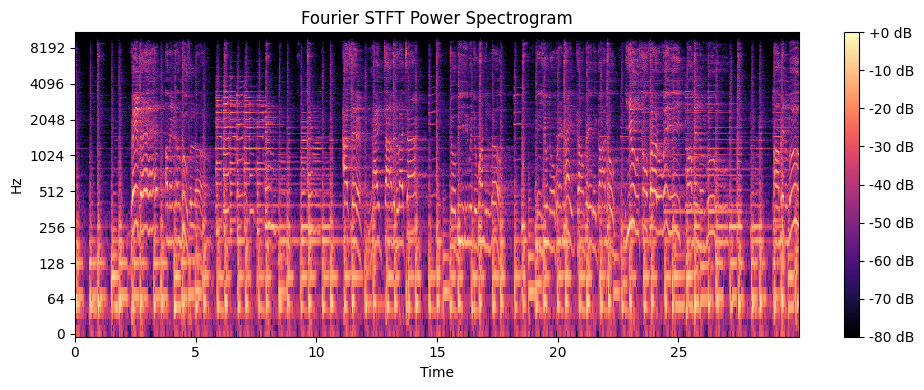

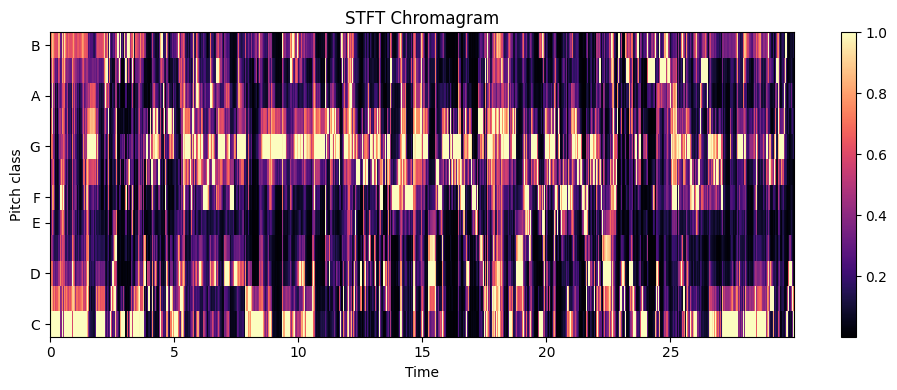

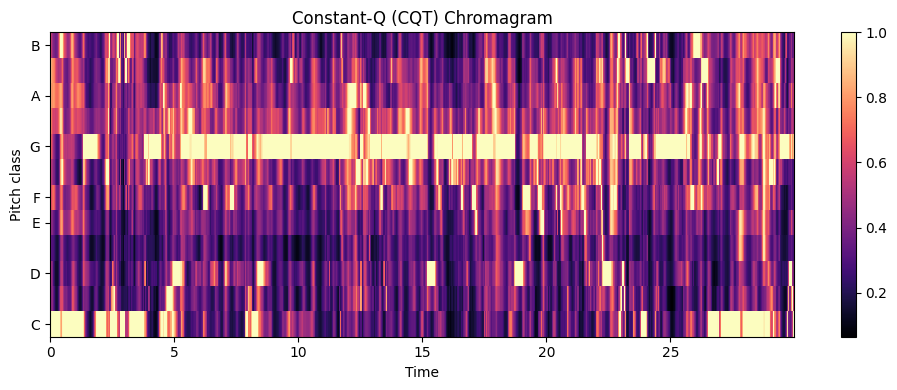

In [8]:
def plot_separate_audio_features(file_path, hop_length=HOP_LENGTH):
    """
    Takes a .wav file path as input and plots its STFT spectrogram, 
    STFT chromagram, and Constant-Q chromagram as separate figures.
    """
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, sr=None, duration=30)
    except Exception as e:
        print(f"Error loading the file: {e}")
        return

    # Compute all features first
    D = librosa.stft(y, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=hop_length)
    chroma_cq = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop_length)

    # --- Plot 1: Fourier STFT Spectrogram ---
    plt.figure(figsize=(10, 4))
    img1 = librosa.display.specshow(S_db, y_axis='log', x_axis='time', sr=sr)
    plt.title('Fourier STFT Power Spectrogram')
    plt.colorbar(img1, format="%+2.0f dB")
    plt.tight_layout()
    plt.savefig('stft_spectrogram.png') # Uncomment to save as an image file

    # --- Plot 2: STFT Chromagram ---
    plt.figure(figsize=(10, 4))
    img2 = librosa.display.specshow(chroma_stft, y_axis='chroma', x_axis='time', sr=sr)
    plt.title('STFT Chromagram')
    plt.colorbar(img2)
    plt.tight_layout()
    plt.savefig('stft_chromagram.png') # Uncomment to save as an image file

    # --- Plot 3: Constant-Q (CQT) Chromagram ---
    plt.figure(figsize=(10, 4))
    img3 = librosa.display.specshow(chroma_cq, y_axis='chroma', x_axis='time', sr=sr)
    plt.title('Constant-Q (CQT) Chromagram')
    plt.colorbar(img3)
    plt.tight_layout()
    plt.savefig('cqt_chromagram.png') # Uncomment to save as an image file

    # Display all generated figures
    plt.show()

# Example usage:
plot_separate_audio_features("../gtzan/Data/genres_original/blues/blues.00001.wav")

In [6]:
# Load audio
y, sr = librosa.load(WAV_FILE, sr=None, mono=True)
print(f"Sample rate : {sr} Hz")
print(f"Duration    : {len(y) / sr:.2f}s")

Sample rate : 22050 Hz
Duration    : 30.01s


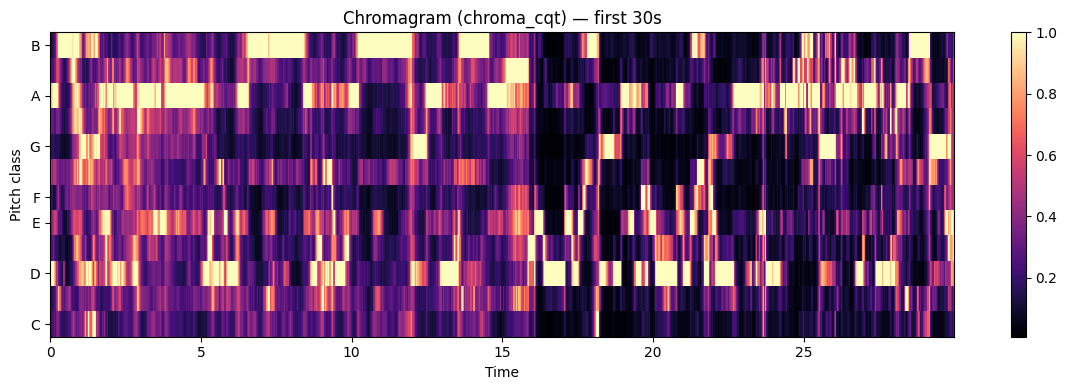

In [7]:
# Chromagram (chroma_cqt) — first 30 seconds
CHROMA_DURATION = 30  # seconds

y, sr = librosa.load(WAV_FILE, sr=None, mono=True, duration=CHROMA_DURATION)

y_harmonic, y_percussive = librosa.effects.hpss(y)

def get_chromagram(y, sr):
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=HOP_LENGTH)

    fig, ax = plt.subplots(figsize=(12, 4))
    img = librosa.display.specshow(
        chroma,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="chroma",
        ax=ax,
    )
    fig.colorbar(img, ax=ax)
    ax.set_title(f"Chromagram (chroma_cqt) — first {CHROMA_DURATION}s")
    plt.tight_layout()
    plt.show()

    return chroma

chroma = get_chromagram(y_harmonic, sr)

In [61]:

PITCH_CLASSES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
WINDOW_DURATION = 0.5  # seconds

frame_duration = HOP_LENGTH / sr
window_frames = max(1, int(WINDOW_DURATION / frame_duration))
n_frames = chroma.shape[1]

# Build 0.5s windows and get top-3 pitches (ordered by energy, descending)
windows = []
for start_f in range(0, n_frames, window_frames):
    end_f = min(start_f + window_frames, n_frames)
    mean_energy = chroma[:, start_f:end_f].mean(axis=1)
    top3 = tuple(np.argsort(mean_energy)[::-1][:3])
    t_start = start_f * frame_duration
    t_end = end_f * frame_duration
    windows.append((top3, t_start, t_end))

# Print only on changes
print("Top-3 dominant pitches per 0.5s window (shown on change):\n")
print(f"{'Start':>8}  {'End':>8}  Notes")
print("-" * 38)

prev_top3 = None
for top3, t_start, t_end in windows:
    if top3 != prev_top3:
        notes = '  '.join(PITCH_CLASSES[i] for i in top3)
        print(f"{t_start:>7.2f}s  {t_end:>7.2f}s  {notes}")
        prev_top3 = top3


Top-3 dominant pitches per 0.5s window (shown on change):

   Start       End  Notes
--------------------------------------
   0.00s     0.49s  C  F  E
   0.98s     1.46s  C  F  G
   1.46s     1.95s  F  C#  C
   1.95s     2.44s  C#  F  G#
   2.44s     2.93s  F  G#  C#
   2.93s     3.41s  F  D  C#
   3.41s     3.90s  D  C  F
   3.90s     4.39s  C  F  B
   4.39s     4.88s  B  C  F
   4.88s     5.36s  A#  B  F
   5.85s     6.34s  A#  A  F
   6.34s     6.83s  F  A  E
   6.83s     7.31s  F  E  C
   7.31s     7.80s  F  A  C
   7.80s     8.29s  C  F  B
   8.29s     8.78s  G  C  E
   8.78s     9.26s  G  E  G#
   9.26s     9.75s  F  A  E
   9.75s    10.24s  F  C  F#
  10.24s    10.73s  F  C  A#
  10.73s    11.22s  A  A#  F
  11.22s    11.70s  A  F  E
  11.70s    12.19s  F  G  C
  12.19s    12.68s  F  G  F#
  12.68s    13.17s  F  F#  E
  13.17s    13.65s  A  G#  F
  13.65s    14.14s  A  F  G#
  14.14s    14.63s  G#  F  A
  14.63s    15.12s  F  E  D#
  15.12s    15.60s  A  G#  F
  15.60s    16.09

In [2]:
# Extract chords from WAV_FILE using chord-extractor (Chordino)
from chord_extractor.extractors import Chordino

chordino = Chordino(roll_on=1)
chords = chordino.extract(WAV_FILE)

print(f"{'Timestamp':>10}  Chord")
print("-" * 22)
for c in chords:
    print(f"{c.timestamp:>9.2f}s  {c.chord}")

/Users/xbaca/Desktop/UC3M/Thesis/chordcluster/.venv/lib/python3.13/site-packages/chord_extractor/extractors/chordino.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
Please make sure VAMP_PATH is specified pointing to the directory containing the appropriate compiled library for Chordino. This can be sourced by using the Vamp Plugin Pack installer at https://code.soundsoftware.ac.uk/projects/vamp-plugin-pack


 Timestamp  Chord
----------------------
     0.37s  N
     1.67s  D
     2.97s  A
     5.02s  Dmaj7
     6.50s  Bm7
    14.58s  A
    15.70s  D6
    18.11s  G
    18.85s  Dm
    21.18s  D6
    29.16s  G6
    30.37s  N


Parsing rules:
'N' -> removed from list,
'X' or 'Xb' where X is a capital letter -> capitalized roman numeral,
'Xmaj' -> treat the same as 'X',
'Xm' where X is a capital letter -> lowercase roman numeral,
'Xaug' -> treat the same as 'X',
'X/%' where % is one capital letter and % is a different capital letter -> treat the same as 'X'
'#n' where # is any of the above expression and n is a digit 1-9 -> treat the same as '#' and then add the number 'n' to the end of the resulting roman numeral


## Key Determination

In [9]:
# Taken from: https://gist.github.com/bmcfee/1f66825cef2eb34c839b42dddbad49fd

import scipy.linalg
from scipy.stats import zscore

from dataclasses import dataclass
from typing import List


@dataclass
class KeyEstimator:

    # adapted from:
    # https://gist.github.com/bmcfee/1f66825cef2eb34c839b42dddbad49fd

    # Coefficients from Kumhansl and Schmuckler
    # as reported here: http://rnhart.net/articles/key-finding/
    major = np.asarray(
        [6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88]
    )
    minor = np.asarray(
        [6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17]
    )

    def __post_init__(self):
        self.major = zscore(self.major)
        self.major_norm = scipy.linalg.norm(self.major)
        self.major = scipy.linalg.circulant(self.major)

        self.minor = zscore(self.minor)
        self.minor_norm = scipy.linalg.norm(self.minor)
        self.minor = scipy.linalg.circulant(self.minor)

    def __call__(self, x: np.array) -> tuple[np.array, np.array]:

        x = zscore(x)
        x_norm = scipy.linalg.norm(x)

        coeffs_major = self.major.T.dot(x) / self.major_norm / x_norm
        coeffs_minor = self.minor.T.dot(x) / self.minor_norm / x_norm

        return coeffs_major, coeffs_minor

In [11]:
# Compute the Chroma Short-Time Fourier Transform (chroma_stft)
chromagram = librosa.feature.chroma_stft(y=y_harmonic, sr=sr, hop_length=HOP_LENGTH)

# Calculate the mean chroma feature across time
mean_chroma = np.mean(chromagram, axis=1)

key_predictions = KeyEstimator()(mean_chroma)

keys = ['C Major', 'Db Major', 'D Major', 'Eb Major', 'E Major', 'F Major', 'Gb Major', 'G Major', 'Ab Major', 'A Major', 'Bb Major', 'B Major', # major keys
        'C Minor', 'Db Minor', 'D Minor', 'Eb Minor', 'E Minor', 'F Minor', 'Gb Minor', 'G Minor', 'Ab Minor', 'A Minor', 'Bb Minor', 'B Minor']  # minor keys

key_predictions = np.concatenate([key_predictions[0], key_predictions[1]])  # Combine major and minor predictions
print(key_predictions)
predicted_key_index = np.argmax(key_predictions)

predicted_key = keys[predicted_key_index]
print(f"Predicted key: {predicted_key}")

[-0.3041551  -0.2434836   0.62697898 -0.47435937  0.46765002 -0.17060415
 -0.10337223 -0.06082492 -0.47539682  0.90276894 -0.20256333  0.03736158
 -0.67568663  0.34971478  0.39759099 -0.13477751  0.07828444 -0.55078361
  0.54770368 -0.26156536 -0.13281982  0.34080204 -0.21400494  0.25554194]
Predicted key: A Major


In [14]:
romanized_chords, final_predicted_key = get_best_romanized_chords(predicted_key, chords)

Key selected: D Major  (* counts: {'A Major': 2, 'E Major': 7, 'D Major': 0, 'Gb Minor': 2, 'A Minor': 0})


- For songs which are NOT minor, not in classical/disco/blues, use manually-labeled key

In [66]:
def get_chromagram(y, sr, duration):
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=HOP_LENGTH)

    fig, ax = plt.subplots(figsize=(12, 4))
    img = librosa.display.specshow(
        chroma,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="chroma",
        ax=ax,
    )
    fig.colorbar(img, ax=ax)
    ax.set_title(f"Chromagram (chroma_stft) — first {duration}s")
    plt.tight_layout()
    plt.show()

    return chroma

In [67]:
def analyze_song(wav_file: str, duration = 30) -> tuple[str, str, np.ndarray]:
    """
    Full pipeline:
      1. Load audio and apply HPSS
      2. Extract chords with Chordino
      3. Predict key with KeyEstimator
      4. Romanize chords, switching key to minimize out-of-key chords
      5. Compute and return the mode, final key, and chord-change transition matrix

    Returns: (mode: str, final_key: str, matrix: np.ndarray)
    """
    sharp_to_flat = {'C#': 'Db', 'D#': 'Eb', 'E#': 'F', 'F#': 'Gb',
                     'G#': 'Ab', 'A#': 'Bb', 'B#': 'C'}

    def normalize_chord(chord_str):
        if len(chord_str) > 1 and chord_str[1] == '#':
            return sharp_to_flat[chord_str[:2]] + chord_str[2:]
        return chord_str

    y, sr = librosa.load(wav_file, sr=None, mono=True, duration=duration)
    y_harmonic, _ = librosa.effects.hpss(y)

    chordino  = Chordino(roll_on=1)
    raw_chords = chordino.extract(wav_file, duration = duration)
    chords     = [c._replace(chord=normalize_chord(c.chord)) for c in raw_chords]

    chromagram = get_chromagram(y_harmonic, sr, duration)
    mean_chroma = np.mean(chromagram, axis=1)
    coeffs_major, coeffs_minor = KeyEstimator()(mean_chroma)

    pitch_classes = ['C', 'Db', 'D', 'Eb', 'E', 'F', 'Gb', 'G', 'Ab', 'A', 'Bb', 'B']
    all_coeffs  = np.concatenate([coeffs_major, coeffs_minor])
    best_idx    = np.argmax(all_coeffs)
    predicted_key = (f"{pitch_classes[best_idx % 12]} Major"
                     if best_idx < 12 else
                     f"{pitch_classes[best_idx % 12]} Minor")
    print(f"Predicted key: {predicted_key}")

    romanized, final_key = get_best_romanized_chords(predicted_key, chords)
    print(f"Chords (raw):   {[c.chord for c in chords if c.chord != 'N']}")
    print(f"Chord sequence: {romanized}")

    mode = "Major" if final_key.endswith(" Major") else "Minor"
    
    return mode, final_key, chord_change_matrix(final_key, romanized)

Predicted key: D Major
Key selected: G Major  (breaks: {'D Major': 56, 'G Major': 1, 'A Major': 101, 'B Minor': 56, 'D Minor': 2}, tonics: {'D Major': 45, 'G Major': 45, 'A Major': 3, 'B Minor': 2, 'D Minor': 45})
Chords (raw):   ['Gmaj7', 'D', 'C', 'G', 'D', 'C', 'G', 'D', 'C6', 'G6', 'D', 'C', 'D6', 'Cmaj7', 'D6', 'Cmaj7', 'G', 'D6', 'C', 'Gmaj7', 'C', 'G', 'Cmaj7', 'G6', 'D', 'Cmaj7', 'G', 'D6', 'Cmaj7', 'G', 'D', 'C', 'G', 'D6', 'Cmaj7', 'G6', 'D', 'Cmaj7', 'G6', 'D', 'C', 'G6', 'D', 'C', 'G', 'D', 'Cmaj7', 'D', 'C', 'G/D', 'C', 'Em7', 'C6', 'D', 'C', 'D', 'C6', 'D', 'C', 'D', 'G/A', 'D6', 'Cmaj7', 'G', 'D', 'Cmaj7', 'G', 'D6', 'Cmaj7', 'G', 'D', 'Cmaj7', 'Gmaj7', 'C6', 'G', 'Cmaj7', 'G', 'D', 'C', 'G', 'D6', 'C6', 'D', 'C', 'D', 'C', 'D', 'C', 'G', 'D6', 'C', 'D', 'Cmaj7', 'D', 'C6', 'Gmaj7', 'D7', 'G', 'C', 'G', 'D', 'Cmaj7', 'G6', 'D', 'C', 'G', 'D', 'C6', 'G/D', 'Cmaj7', 'G', 'D', 'Cmaj7', 'G/D', 'Cmaj7', 'Gm', 'D', 'C', 'G', 'Am7', 'Cmaj7', 'G', 'Bm7b5/A', 'C6', 'Bm', 'Am', 'G

([<matplotlib.axis.XTick at 0x130a0fc50>,
 [Text(0, 0, 'I'),
  Text(1, 0, 'ii'),
  Text(2, 0, 'iii'),
  Text(3, 0, 'IV'),
  Text(4, 0, 'V'),
  Text(5, 0, 'vi'),
  Text(6, 0, 'vii°'),
  Text(7, 0, '*')])

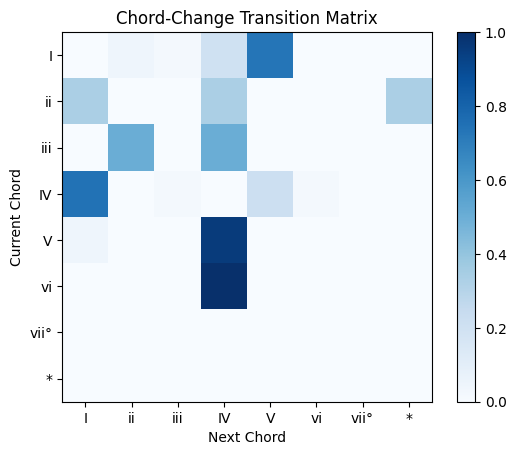

In [8]:
#mode, key, markov_matrix = analyze_song("../gtzan/Data/genres_original/classical/classical.00079.wav", 30)
mode, key, raw_chords, romanized_chords, markov_matrix = analyze_song("../Semi-Charmed Life.flac")
#mode, key, raw_chords, romanized_chords, markov_matrix = analyze_song("../Si te vas....wav", duration=150)#

if mode == "Major":
    labels = ['I', 'ii', 'iii', 'IV', 'V', 'vi', 'vii°', '*']
else:
    labels = ['i', 'ii°', 'III', 'iv', 'v', 'VI', 'VII', '*']

plt.imshow(markov_matrix, cmap='Blues')
plt.colorbar()
plt.title("Chord-Change Transition Matrix")
plt.xlabel("Next Chord")
plt.ylabel("Current Chord")
plt.yticks(ticks=np.arange(8), labels=labels)
plt.xticks(ticks=np.arange(8), labels=labels)

In [37]:
get_steady_state(markov_matrix)

array([0.33333333, 0.        , 0.        , 0.33333333, 0.33333333,
       0.        , 0.        , 0.        ])

In [ ]:
import glob
import os

def analyze_all_songs(root_dir: str) -> dict:
    """
    Run analyze_song on every .wav file under root_dir and store results in a
    nested dictionary keyed by mode, then by song title.

    Returns:
        {
            "Major": { "song_title": {"matrix": np.ndarray, "key": str}, ... },
            "Minor": { "song_title": {"matrix": np.ndarray, "key": str}, ... },
        }
    """
    wav_files = glob.glob(f"{root_dir}/**/*.wav", recursive=True)
    print(f"Found {len(wav_files)} .wav files\n")

    results = {"Major": {}, "Minor": {}}

    for i, wav_file in enumerate(wav_files):
        title = os.path.splitext(os.path.basename(wav_file))[0]
        print(f"[{i+1}/{len(wav_files)}] {title}")
        try:
            mode, key, matrix = analyze_song(wav_file)
            if matrix.sum() == 0:
                print("  SKIPPED: <= 1 chord detected, no transitions to record.")
                continue
            results[mode][title] = {"matrix": matrix, "key": key}
        except Exception as e:
            print(f"  ERROR: {e}")
        print()

    return results

markov_matrices = analyze_all_songs("../gtzan/Data/genres_original")

In [36]:
def get_steady_state(matrix: np.ndarray) -> np.ndarray:
    """
    Compute the steady-state distribution of a row-stochastic Markov matrix.
    Finds the left eigenvector of P corresponding to eigenvalue 1,
    i.e. the right eigenvector of P^T with eigenvalue 1.
    """
    eigenvalues, eigenvectors = np.linalg.eig(matrix.T)
    idx = np.argmin(np.abs(eigenvalues - 1))
    steady_state = eigenvectors[:, idx].real
    steady_state = np.abs(steady_state)
    return steady_state / steady_state.sum()

major_songs   = markov_matrices["Major"]
major_titles  = list(major_songs.keys())
major_steady_states = np.array([
    get_steady_state(major_songs[t]["matrix"]) for t in major_titles
])
print(f"Steady-state vectors shape: {major_steady_states.shape}")

NameError: name 'markov_matrices' is not defined

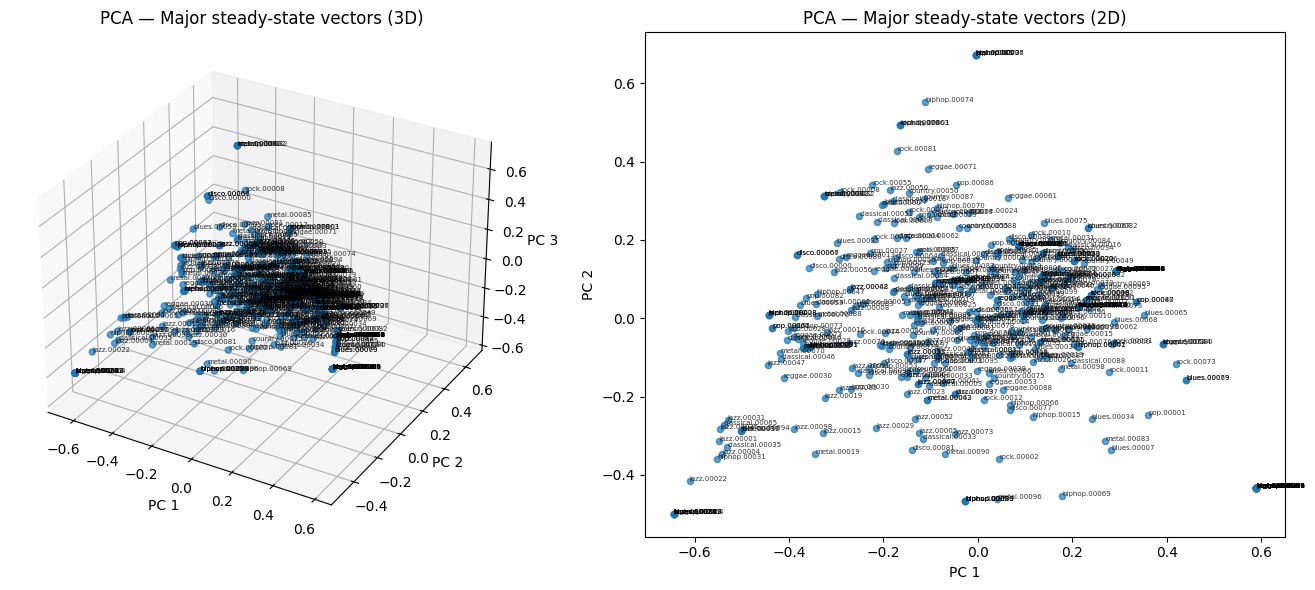

In [102]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# --- Dimensionality reduction ---
pca_3d_coords = PCA(n_components=3).fit_transform(major_steady_states)
pca_2d_coords = PCA(n_components=2).fit_transform(major_steady_states)

# --- Plot ---
fig = plt.figure(figsize=(14, 6))

# 3D PCA
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(pca_3d_coords[:, 0], pca_3d_coords[:, 1], pca_3d_coords[:, 2], s=20, alpha=0.7)
for i, song_title in enumerate(major_titles):
    ax1.text(pca_3d_coords[i, 0], pca_3d_coords[i, 1], pca_3d_coords[i, 2],
             song_title, fontsize=5, alpha=0.8)
ax1.set_title("PCA — Major steady-state vectors (3D)")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.set_zlabel("PC 3")

# 2D PCA
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(pca_2d_coords[:, 0], pca_2d_coords[:, 1], s=20, alpha=0.7)
for i, song_title in enumerate(major_titles):
    ax2.annotate(song_title, (pca_2d_coords[i, 0], pca_2d_coords[i, 1]),
                 fontsize=5, alpha=0.8)
ax2.set_title("PCA — Major steady-state vectors (2D)")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")

plt.tight_layout()
plt.show()

Steady-state distribution of chords:
I: 0.3333
ii: 0.0000
iii: 0.0000
IV: 0.3333
V: 0.3333
vi: -0.0000
vii°: -0.0000
X: -0.0000


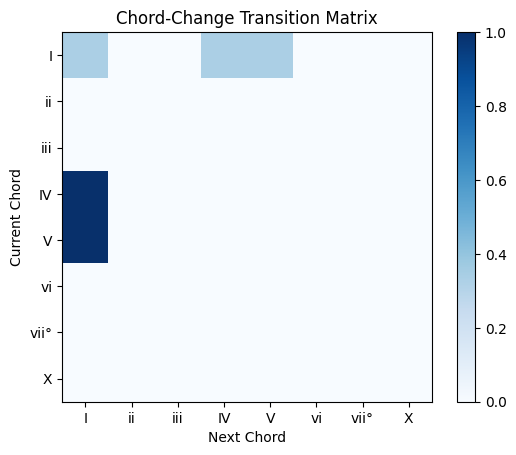

In [ ]:
def steady_state_vec(matrix):
    matrix = matrix.T  # Transpose to get correct orientation for Markov chain
    dim = matrix.shape[0]
    q = (matrix - np.eye(dim))
    ones = np.ones(dim)
    q = np.c_[q, ones]
    QTQ = np.dot(q, q.T)
    bQT = np.ones(dim)

    return np.linalg.solve(QTQ, bQT)

example = markov_matrices["Major"][300]

labels = ['I', 'ii', 'iii', 'IV', 'V', 'vi', 'vii°', '*']

plt.imshow(example, cmap='Blues')
plt.colorbar()
plt.title("Chord-Change Transition Matrix")
plt.xlabel("Next Chord")
plt.ylabel("Current Chord")
plt.yticks(ticks=np.arange(8), labels=labels)
plt.xticks(ticks=np.arange(8), labels=labels)


example = steady_state_vec(example)  # Example: first Major matrix
print("Steady-state distribution of chords:")
for label, prob in zip(labels, example):
    print(f"{label}: {prob:.4f}")

In [ ]:
from scipy.optimize import minimize

# ── Inner Simplex Algorithm (ISA) ─────────────────────────────────────────────
def _isa(X, m):
    """
    Find m rows of X that best represent the vertices of the data simplex.
    Uses sequential Gram-Schmidt orthogonalisation to locate extremal points.
    """
    B = X.copy().astype(float)
    vertices = [int(np.argmax(np.linalg.norm(B, axis=1)))]
    for _ in range(1, m):
        v = B[vertices[-1]].copy()
        norm = np.linalg.norm(v)
        if norm > 1e-12:
            v /= norm
            B -= np.outer(B @ v, v)
        norms = np.linalg.norm(B, axis=1)
        for vi in vertices:
            norms[vi] = -np.inf
        vertices.append(int(np.argmax(norms)))
    return vertices


# ── PCCA+ ─────────────────────────────────────────────────────────────────────
def pcca_plus(P, m):
    """
    PCCA+ spectral clustering algorithm (arXiv:2206.14537).

    Finds m metastable clusters of the n states of a row-stochastic Markov
    chain by computing a fuzzy membership matrix χ = X·A, where X contains
    the m dominant right eigenvectors of P and A is optimised for crispness.

    Args:
        P : (n, n) row-stochastic transition matrix
        m : number of metastable clusters

    Returns:
        chi : (n, m) membership matrix  - rows sum to 1, values in [0, 1]
        A   : (m, m) optimal transformation matrix
    """
    n = P.shape[0]
    assert 1 < m <= n, "m must satisfy 1 < m ≤ n"

    # ── Step 1: m dominant right eigenvectors of P ───────────────────────────
    eigenvalues, eigenvectors = np.linalg.eig(P)
    order = np.argsort(eigenvalues.real)[::-1]          # descending |λ|
    X = eigenvectors[:, order[:m]].real                 # (n, m)

    # ── Step 2: ISA – initial transformation from simplex vertices ───────────
    vertices = _isa(X, m)
    S  = X[vertices, :]          # (m, m) vertex submatrix
    A0 = np.linalg.inv(S)        # initial A

    # ── Step 3: Maximise crispness  Σᵢⱼ χᵢⱼ²  (= minimise –Σ χ²) ──────────
    #   subject to  χ = X·A ∈ [0,1]  and  χ·1 = 1  (via penalty terms)
    def neg_crispness(a_flat):
        A   = a_flat.reshape(m, m)
        chi = X @ A
        obj = -np.sum(chi ** 2)
        pen = 1e4 * (
            np.sum(np.maximum(0.0, -chi) ** 2) +          # chi ≥ 0
            np.sum(np.maximum(0.0,  chi - 1.0) ** 2) +   # chi ≤ 1
            np.sum((chi.sum(axis=1) - 1.0) ** 2)          # rows sum to 1
        )
        return obj + pen

    result = minimize(
        neg_crispness, A0.flatten(), method="Nelder-Mead",
        options={"maxiter": 100_000, "xatol": 1e-10, "fatol": 1e-10, "adaptive": True},
    )
    A_opt = result.x.reshape(m, m)

    # ── Step 4: Build and normalise membership matrix ────────────────────────
    chi = X @ A_opt
    chi = np.clip(chi, 0.0, 1.0)
    chi /= chi.sum(axis=1, keepdims=True)

    return chi, A_opt

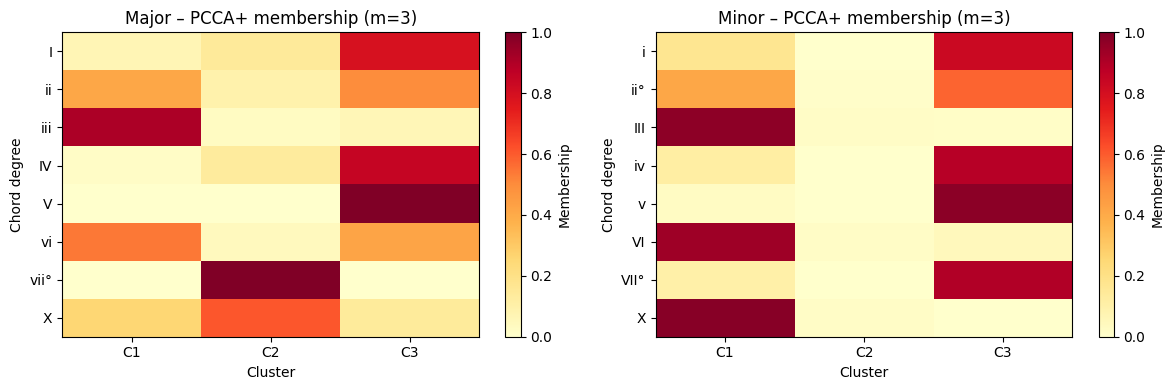

In [129]:
# Apply PCCA+ to the mean transition matrix for each mode
# m = number of metastable chord clusters to find
M = 3

chord_labels = {
    "Major": ["I", "ii", "iii", "IV", "V", "vi", "vii°", "X"],
    "Minor": ["i", "ii°", "III", "iv", "v", "VI", "VII°", "X"],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mode in zip(axes, ["Major", "Minor"]):
    matrices = np.array([v["matrix"] for v in markov_matrices[mode].values()])
    mean_P   = matrices.mean(axis=0)          # average transition matrix

    chi, _ = pcca_plus(mean_P, M)

    im = ax.imshow(chi, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, label="Membership")
    ax.set_title(f"{mode} – PCCA+ membership (m={M})")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Chord degree")
    ax.set_xticks(range(M),      [f"C{i+1}" for i in range(M)])
    ax.set_yticks(range(8),      chord_labels[mode])

plt.tight_layout()
plt.show()

In [16]:
def get_KS_key(y_harmonic, sr):
    # Get chroma features
    chromagram  = librosa.feature.chroma_stft(y=y_harmonic, sr=sr, hop_length=512)
    mean_chroma = np.mean(chromagram, axis=1)

    # Use KS algorithm to make an initial prediction of the key
    coeffs_major, coeffs_minor = KeyEstimator()(mean_chroma)
    pitch_classes = ['C', 'Db', 'D', 'Eb', 'E', 'F', 'Gb', 'G', 'Ab', 'A', 'Bb', 'B']
    all_coeffs    = np.concatenate([coeffs_major, coeffs_minor])
    best_idx      = np.argmax(all_coeffs)
    predicted_key = (f"{pitch_classes[best_idx % 12]} Major"
                        if best_idx < 12 else
                        f"{pitch_classes[best_idx % 12]} Minor")
    print(f"Predicted key: {predicted_key}")
    return predicted_key

import io
import contextlib
import glob
import os

# ── Step 1: Run KS key prediction for every song ──────────────────────────────
DATA_ROOT = "../gtzan/Data/genres_original"
wav_files = sorted(glob.glob(f"{DATA_ROOT}/**/*.wav", recursive=True))
print(f"Found {len(wav_files)} .wav files — predicting KS key for each...")

ks_results = []
for i, wav_file in enumerate(wav_files):
    fname = os.path.basename(wav_file)
    try:
        y, sr = librosa.load(wav_file, sr=None, mono=True, duration=30)
        y_harmonic, _ = librosa.effects.hpss(y)
        with contextlib.redirect_stdout(io.StringIO()):  # suppress per-song print
            ks_key = get_KS_key(y_harmonic, sr)
    except Exception as e:
        print(f"  ERROR {fname}: {e}")
        ks_key = None
    ks_results.append({"File Name": fname, "KS Key": ks_key})
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{len(wav_files)} done...")

ks_df = pd.DataFrame(ks_results)
print(f"Done — {ks_df['KS Key'].notna().sum()} keys predicted successfully.\n")

Found 1000 .wav files — predicting KS key for each...
  200/1000 done...
  400/1000 done...


/var/folders/74/0jlfght16sbdd6_76x5j4gv80000gn/T/ipykernel_94660/4085159034.py:31: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(wav_file, sr=None, mono=True, duration=30)
/Users/xbaca/Desktop/UC3M/Thesis/chordcluster/.venv/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  ERROR jazz.00054.wav: 
  600/1000 done...
  800/1000 done...
  1000/1000 done...
Done — 999 keys predicted successfully.



In [17]:
# ── Step 2: Parse "Key Name" short notation → standard "X Major"/"X Minor" ───
_sharp_to_flat = {
    'A#': 'Bb', 'B#': 'C', 'C#': 'Db', 'D#': 'Eb',
    'E#': 'F',  'F#': 'Gb', 'G#': 'Ab',
}

def _parse_key_name(key_name):
    """'Gm' → 'G Minor',  'A#m' → 'Bb Minor',  'D' → 'D Major'."""
    if not isinstance(key_name, str):
        return None
    kn = key_name.strip()
    if kn.lower() in ('unknown', 'unknown/modulation'):
        return None
    is_minor = kn.endswith('m')
    tonic = kn[:-1] if is_minor else kn
    tonic = _sharp_to_flat.get(tonic, tonic)
    return f"{tonic} {'Minor' if is_minor else 'Major'}"

# ── Step 3: Categorise each (GT key, predicted key) pair ──────────────────────
_cof = circle_of_fifths  # {'Major': [...], 'Minor': [...]}

def categorize_prediction(gt_key_name_raw, pred_key):
    if not isinstance(gt_key_name_raw, str) or \
            gt_key_name_raw.strip().lower() in ('unknown', 'unknown/modulation'):
        return "N/A"
    gt_key = _parse_key_name(gt_key_name_raw)
    if gt_key is None:
        return "N/A"
    if not isinstance(pred_key, str):     # handles None / NaN
        return "Other"

    gt_tonic, gt_mode = gt_key.split()
    pred_tonic, pred_mode = pred_key.split()

    if gt_tonic == pred_tonic and gt_mode == pred_mode:
        return "Match"

    if gt_tonic == pred_tonic:               # same tonic, different mode
        return "Parallel predicted"

    if gt_tonic not in _cof[gt_mode]:        # shouldn't happen with clean data
        return "Other"

    gt_idx     = _cof[gt_mode].index(gt_tonic)
    other_mode = "Minor" if gt_mode == "Major" else "Major"

    # Relative key (same position on the other mode's CoF)
    if pred_tonic == _cof[other_mode][gt_idx] and pred_mode == other_mode:
        return "Relative predicted"

    # Fifth of GT key (one step clockwise on same-mode CoF)
    if pred_tonic == _cof[gt_mode][(gt_idx + 1) % 12] and pred_mode == gt_mode:
        return "Fifth predicted"

    # Fourth of GT key (one step counter-clockwise on same-mode CoF)
    if pred_tonic == _cof[gt_mode][(gt_idx - 1) % 12] and pred_mode == gt_mode:
        return "Fourth predicted"

    return "Other"

# ── Step 4: Per-genre breakdown helper ────────────────────────────────────────
category_order = ["Match", "Fifth predicted", "Fourth predicted",
                  "Relative predicted", "Parallel predicted", "Other", "N/A"]

def category_breakdown(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    """Print per-genre percentages and overall summary; return the per-genre table."""
    per_genre = (
        pd.crosstab(frame["Genre"], frame["Category"], normalize="index") * 100
    ).reindex(columns=category_order, fill_value=0).round(1)
    per_genre["Total"] = frame.groupby("Genre").size()
    print(f"{label} — match percentage per genre:")
    print(per_genre.to_string())
    print()

    overall = (
        frame["Category"]
        .value_counts()
        .reindex(category_order, fill_value=0)
        .reset_index()
    )
    overall.columns = ["Category", "Count"]
    overall["Percentage"] = (overall["Count"] / len(frame) * 100).round(1)
    print(f"{label} — overall:")
    print(overall.to_string(index=False))
    return per_genre

# ── Step 5: Merge KS predictions with df and categorise ───────────────────────
merged = df.merge(ks_df, on="File Name", how="left")
merged["Category"] = merged.apply(
    lambda r: categorize_prediction(r["Key Name"], r["KS Key"]), axis=1
)

ks_per_genre = category_breakdown(merged, "KS Key vs Key Name")

KS Key vs Key Name — match percentage per genre:
Category   Match  Fifth predicted  Fourth predicted  Relative predicted  Parallel predicted  Other   N/A  Total
Genre                                                                                                          
blues       23.0              6.0               2.0                 0.0                39.0   28.0   2.0    100
classical    0.0              0.0               0.0                 0.0                 0.0    1.0  99.0    100
country     55.0             32.0               0.0                 4.0                 2.0    7.0   0.0    100
disco       35.0             20.0               2.0                 6.0                16.0   19.0   2.0    100
hiphop      13.0             12.0               3.0                 5.0                11.0   37.0  19.0    100
jazz        22.0             12.0               3.0                 8.0                 9.0   25.0  21.0    100
metal       37.0             11.0               1.0    

In [11]:
# ── Enhanced KS Key: KeyEstimator refined by get_best_romanized_chords ───────
# Run analyze_all_songs with ignore_GT_key=True so it never falls back to the
# GT key — the returned "key" is the KS prediction after get_best_romanized_chords.
print("Running analyze_all_songs(..., ignore_GT_key=True) — this will take a while...")
with contextlib.redirect_stdout(io.StringIO()):
    enhanced_results = analyze_all_songs(DATA_ROOT, ignore_GT_key=True)

Running analyze_all_songs(..., ignore_GT_key=True) — this will take a while...


/Users/xbaca/Desktop/UC3M/Thesis/chordcluster/code/song_analysis_utils.py:285: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(wav_file, sr=None, mono=True, duration=duration)
/Users/xbaca/Desktop/UC3M/Thesis/chordcluster/.venv/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [22]:
# Flatten Major/Minor buckets into a per-song mapping.
enhanced_rows = [
    {"File Name": f"{title}.wav", "Enhanced KS Key": info["key"]}
    for mode_bucket in enhanced_results.values()
    for title, info in mode_bucket.items()
]
enhanced_df = pd.DataFrame(enhanced_rows)
print(f"Got Enhanced KS Key for {len(enhanced_df)} songs.\n")

# Merge with df and categorise using the same logic as the plain KS comparison.
enhanced_merged = df.merge(enhanced_df, on="File Name", how="left")
enhanced_merged["KS Key"] = merged["KS Key"]
enhanced_merged = enhanced_merged.dropna()
enhanced_merged["Category"] = enhanced_merged.apply(
    lambda r: categorize_prediction(r["Key Name"], r["Enhanced KS Key"]), axis=1
)

enhanced_per_genre = category_breakdown(enhanced_merged, "Enhanced KS Key vs Key Name")

Got Enhanced KS Key for 911 songs.

Enhanced KS Key vs Key Name — match percentage per genre:
Category   Match  Fifth predicted  Fourth predicted  Relative predicted  Parallel predicted  Other   N/A  Total
Genre                                                                                                          
blues       21.3              8.5               3.2                 0.0                42.6   22.3   2.1     94
classical    0.0              0.0               0.0                 1.0                 0.0    0.0  99.0    100
country     69.7             12.1               0.0                 7.1                 4.0    7.1   0.0     99
disco       45.7             11.7               3.2                 7.4                11.7   18.1   2.1     94
hiphop      14.8             11.1               5.6                 5.6                 9.3   40.7  13.0     54
jazz        22.2             10.1               5.1                 9.1                 8.1   25.3  20.2     99
metal     

In [21]:
new_merged = df.merge(ks_df, on="File Name", how="left")
new_merged = enhanced_df.merge(new_merged, on="File Name", how="left")
new_merged = new_merged.dropna()
new_merged["Category"] = new_merged.apply(
    lambda r: categorize_prediction(r["Key Name"], r["KS Key"]), axis=1
)

ks_per_genre = category_breakdown(new_merged, "KS Key vs Key Name")

KS Key vs Key Name — match percentage per genre:
Category   Match  Fifth predicted  Fourth predicted  Relative predicted  Parallel predicted  Other   N/A  Total
Genre                                                                                                          
blues       24.5              6.4               2.1                 0.0                37.2   27.7   2.1     94
classical    0.0              0.0               0.0                 0.0                 0.0    1.0  99.0    100
country     55.6             32.3               0.0                 4.0                 2.0    6.1   0.0     99
disco       35.1             20.2               2.1                 6.4                16.0   18.1   2.1     94
hiphop      11.1             13.0               5.6                 5.6                14.8   37.0  13.0     54
jazz        22.2             12.1               3.0                 8.1                 9.1   25.3  20.2     99
metal       37.5             10.4               1.0    

In [7]:
WAV = "../gtzan/Data/genres_original/classical/classical.00071.wav"  # <-- change this to your .wav file path
analyze_song(WAV, ignore_GT_key = True)

Predicted key: F Major
Key selected: F Major  (breaks: {'F Major': 1, 'Bb Major': 1, 'C Major': 2, 'D Minor': 1, 'F Minor': 4}, tonics: {'F Major': 4, 'Bb Major': 2, 'C Major': 6, 'D Minor': 3, 'F Minor': 4})
Chords (raw):   ['F', 'Dm', 'F', 'Bb', 'Bdim', 'Cmaj7', 'C7', 'F', 'Gm7b5', 'D7', 'Daug', 'C7/E', 'Bbm', 'C7/E', 'F', 'Gm', 'Cmaj7', 'C']
Chord sequence: ['I', 'vi', 'I', 'IV', '*', 'V', 'V', 'I', 'ii', 'vi', 'vi', 'V', 'IV', 'V', 'I', 'ii', 'V', 'V']


('Major',
 'F Major',
 ['F',
  'Dm',
  'F',
  'Bb',
  'Bdim',
  'Cmaj7',
  'C7',
  'F',
  'Gm7b5',
  'D7',
  'Daug',
  'C7/E',
  'Bbm',
  'C7/E',
  'F',
  'Gm',
  'Cmaj7',
  'C'],
 ['I',
  'vi',
  'I',
  'IV',
  '*',
  'V',
  'V',
  'I',
  'ii',
  'vi',
  'vi',
  'V',
  'IV',
  'V',
  'I',
  'ii',
  'V',
  'V'],
 array([[0.        , 0.5       , 0.        , 0.25      , 0.        ,
         0.25      , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.5       ,
         0.5       , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.5       ,
         0.        , 0.        , 0.5       ],
        [0.4       , 0.        , 0.        , 0.2       , 0.4       ,
         0.        , 0.        , 0.        ],
        [0.33333333, 0.        , 0.        , 0.        , 0.33333333,
         0.33333333, 0.        , 0.       